In [2]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Loading the Dataset FER2013

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


extracted the zip file

In [4]:
zip_path = '/content/drive/MyDrive/MoodMirror/dataset.zip'


In [5]:
import os

extract_path = '/content/dataset'
os.makedirs(extract_path, exist_ok=True)


In [6]:
import zipfile

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


In [7]:
os.listdir(extract_path)


['train', 'test']

In [8]:
train_dir = os.path.join(extract_path, 'train')
test_dir  = os.path.join(extract_path, 'test')


“ImageDataGenerator is used to load FER-2013 images, normalize pixel values, and apply real-time data augmentation to improve CNN generalization while ensuring fair testing.”(Preprocessing)

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator



train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical',

)


Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [10]:
train_generator = train_generator
test_generator = test_generator


In [11]:
import json
import os

# Path to save labels
label_save_path = '/content/drive/MyDrive/MoodMirror/class_labels.json'

# Get class indices from training generator
class_labels = train_generator.class_indices

# Save as JSON
with open(label_save_path, 'w') as f:
    json.dump(class_labels, f, indent=4)

print("✅ class_labels.json created successfully")
print(class_labels)


✅ class_labels.json created successfully
{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


**Exploratory Data Analysis**

In [12]:
import os
import cv2
import matplotlib.pyplot as plt


In [13]:
emotion_labels = sorted(os.listdir(train_dir))

print("Emotion Classes:", emotion_labels)

Emotion Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


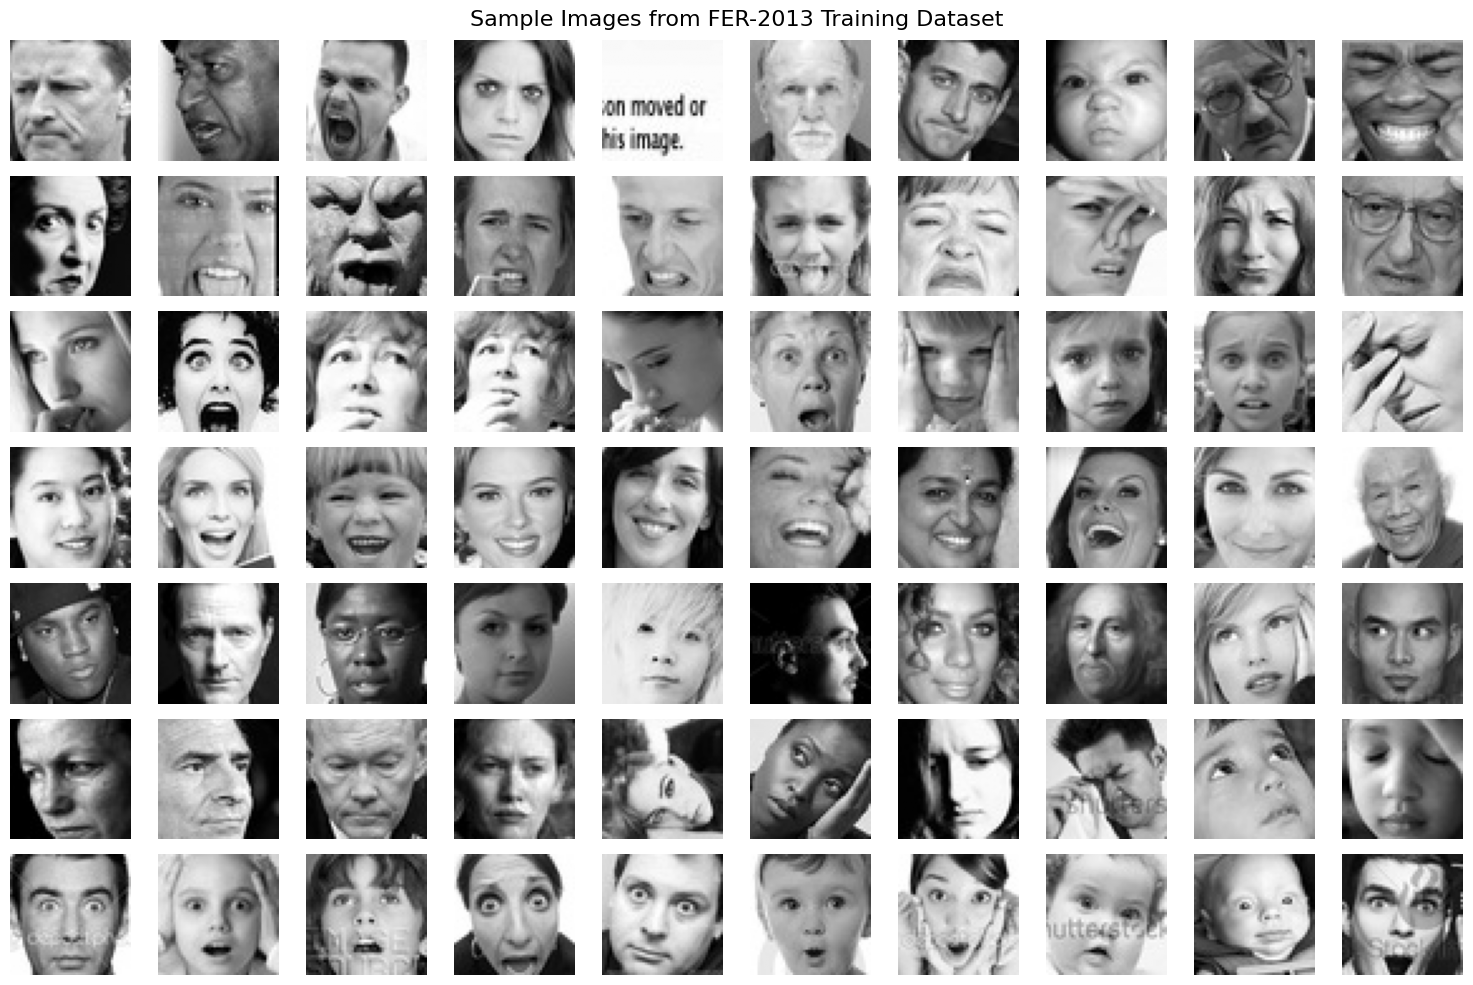

In [14]:
plt.figure(figsize=(15, 10))

img_count = 0

for emotion in emotion_labels:
    emotion_path = os.path.join(train_dir, emotion)
    images = os.listdir(emotion_path)[:10]   # first 10 images

    for img_name in images:
        img_path = os.path.join(emotion_path, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        plt.subplot(len(emotion_labels), 10, img_count + 1)
        plt.imshow(img, cmap='gray')
        plt.axis('off')

        if img_count % 10 == 0:
            plt.ylabel(emotion, fontsize=12)

        img_count += 1

plt.suptitle("Sample Images from FER-2013 Training Dataset", fontsize=16)
plt.tight_layout()
plt.show()


In [15]:
class_counts = {}

for emotion in emotion_labels:
    emotion_path = os.path.join(train_dir, emotion)
    class_counts[emotion] = len(os.listdir(emotion_path))

print('Class Count for Train Dataset are as follow:')
class_counts



Class Count for Train Dataset are as follow:


{'angry': 3995,
 'disgust': 436,
 'fear': 4097,
 'happy': 7215,
 'neutral': 4965,
 'sad': 4830,
 'surprise': 3171}

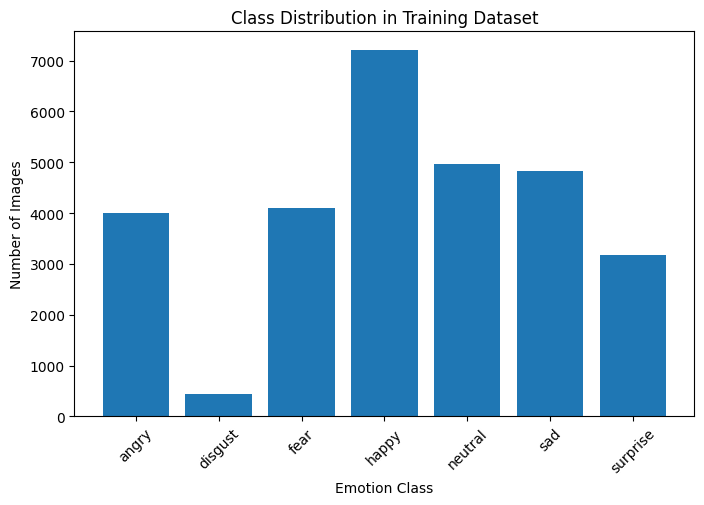

In [16]:
plt.figure(figsize=(8,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Emotion Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution in Training Dataset")
plt.xticks(rotation=45)
plt.show()


In [17]:
class_counts = {}

for emotion in emotion_labels:
    emotion_path = os.path.join(test_dir, emotion)
    class_counts[emotion] = len(os.listdir(emotion_path))

print('Class Count for Test Dataset are as follow:')
class_counts

Class Count for Test Dataset are as follow:


{'angry': 958,
 'disgust': 111,
 'fear': 1024,
 'happy': 1774,
 'neutral': 1233,
 'sad': 1247,
 'surprise': 831}

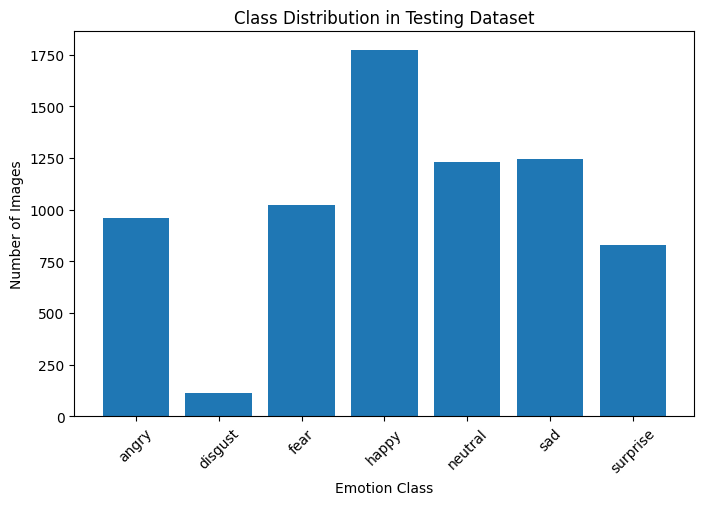

In [18]:
plt.figure(figsize=(8,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Emotion Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution in Testing Dataset")
plt.xticks(rotation=45)
plt.show()

In [19]:
sample_emotion = emotion_labels[0]
sample_img = os.listdir(os.path.join(train_dir, sample_emotion))[0]

img = cv2.imread(os.path.join(train_dir, sample_emotion, sample_img), cv2.IMREAD_GRAYSCALE)
print("Image shape:", img.shape)


Image shape: (48, 48)


In [20]:
sample_emotion = emotion_labels[0]
sample_img = os.listdir(os.path.join(test_dir, sample_emotion))[0]

img = cv2.imread(os.path.join(test_dir, sample_emotion, sample_img), cv2.IMREAD_GRAYSCALE)
print("Image shape:", img.shape)

Image shape: (48, 48)


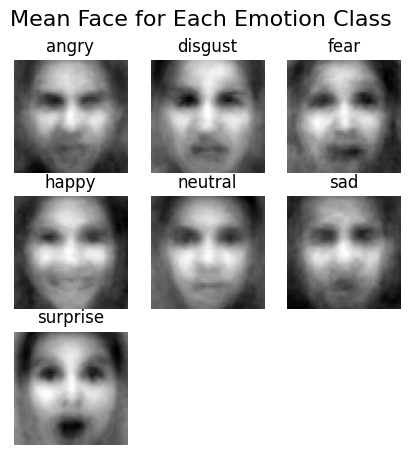

In [21]:
import numpy as np
import cv2

plt.figure(figsize=(5,5))

for i, emotion in enumerate(emotion_labels):
    emotion_path = os.path.join(train_dir, emotion)
    images = os.listdir(emotion_path)[:200]  # sample subset

    mean_img = np.zeros((48,48), dtype=np.float32)

    for img_name in images:
        img = cv2.imread(os.path.join(emotion_path, img_name), cv2.IMREAD_GRAYSCALE)
        mean_img += img

    mean_img /= len(images)

    plt.subplot(3,3,i+1)
    plt.imshow(mean_img, cmap='gray')
    plt.title(emotion)
    plt.axis('off')

plt.suptitle("Mean Face for Each Emotion Class", fontsize=16)
plt.show()


In [22]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
    #for filename in filenames:
        #print(os.path.join(dirname, filename))
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from keras.preprocessing import image
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten,Dense,Dropout,BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
from tensorflow.keras.applications import VGG16, InceptionResNetV2
from keras import regularizers
from tensorflow.keras.optimizers import Adam,RMSprop,SGD,Adamax

In [23]:
"""
Modeling


model = Sequential()
model.add(Conv2D(filters = 64,kernel_size = (3,3),padding = 'same',activation = 'relu',input_shape=(img_size,img_size,1)))
model.add(MaxPool2D(pool_size = 2,strides = 2))
model.add(BatchNormalization())

model.add(Conv2D(filters = 128,kernel_size = (3,3),padding = 'same',activation = 'relu'))
model.add(MaxPool2D(pool_size = 2,strides = 2))
model.add(BatchNormalization())
model.add(Dropout(0.25))

model.add(Conv2D(filters = 128,kernel_size = (3,3),padding = 'same',activation = 'relu'))
model.add(MaxPool2D(pool_size = 2,strides = 2))
model.add(BatchNormalization())
model.add(Dropout(0.25))

model.add(Conv2D(filters = 256,kernel_size = (3,3),padding = 'same',activation = 'relu'))
model.add(MaxPool2D(pool_size = 2,strides = 2))
model.add(BatchNormalization())

model.add(Flatten())
model.add(Dense(units = 128,activation = 'relu',kernel_initializer='he_normal'))
model.add(Dropout(0.25))
model.add(Dense(units = 64,activation = 'relu',kernel_initializer='he_normal'))
model.add(BatchNormalization())
model.add(Dropout(0.25))
model.add(Dense(units = 32,activation = 'relu',kernel_initializer='he_normal'))
model.add(Dense(7,activation = 'softmax'))

"""

"\nModeling\n\n\nmodel = Sequential()\nmodel.add(Conv2D(filters = 64,kernel_size = (3,3),padding = 'same',activation = 'relu',input_shape=(img_size,img_size,1)))\nmodel.add(MaxPool2D(pool_size = 2,strides = 2))\nmodel.add(BatchNormalization())\n\nmodel.add(Conv2D(filters = 128,kernel_size = (3,3),padding = 'same',activation = 'relu'))\nmodel.add(MaxPool2D(pool_size = 2,strides = 2))\nmodel.add(BatchNormalization())\nmodel.add(Dropout(0.25))\n\nmodel.add(Conv2D(filters = 128,kernel_size = (3,3),padding = 'same',activation = 'relu'))\nmodel.add(MaxPool2D(pool_size = 2,strides = 2))\nmodel.add(BatchNormalization())\nmodel.add(Dropout(0.25))\n\nmodel.add(Conv2D(filters = 256,kernel_size = (3,3),padding = 'same',activation = 'relu'))\nmodel.add(MaxPool2D(pool_size = 2,strides = 2))\nmodel.add(BatchNormalization())\n\nmodel.add(Flatten())\nmodel.add(Dense(units = 128,activation = 'relu',kernel_initializer='he_normal'))\nmodel.add(Dropout(0.25))\nmodel.add(Dense(units = 64,activation = 'relu'

In [24]:
model= tf.keras.models.Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu', input_shape=(48, 48,1)))
model.add(Conv2D(64,(3,3), padding='same', activation='relu' ))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(128,(5,5), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(512,(3,3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(512,(3,3),padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(256,activation = 'relu'))
model.add(BatchNormalization())
model.add(Dropout(0.25))

model.add(Dense(512,activation = 'relu'))
model.add(BatchNormalization())
model.add(Dropout(0.25))

model.add(Dense(7, activation='softmax'))

model.compile(
    optimizer = Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
  )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
epochs = 60
batch_size = 64

In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 512)    │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,496,903 (17.15 MB)

 Trainable params: 4,492,935 (17.14 MB)

 Non-trainable params: 3,968 (15.50 KB)

In [ ]:
history = model.fit(x = train_generator,epochs = epochs,validation_data = test_generator)

Epoch 1/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 59s 91ms/step - accuracy: 0.1812 - loss: 9.2147 - val_accuracy: 0.1532 - val_loss: 8.5551
Epoch 2/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 32s 70ms/step - accuracy: 0.2028 - loss: 7.9536 - val_accuracy: 0.2485 - val_loss: 7.1377
Epoch 3/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 28s 62ms/step - accuracy: 0.2139 - loss: 6.7051 - val_accuracy: 0.2605 - val_loss: 5.9281
Epoch 4/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 61ms/step - accuracy: 0.2230 - loss: 5.5208 - val_accuracy: 0.2666 - val_loss: 4.8098
Epoch 5/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.2311 - loss: 4.5006 - val_accuracy: 0.2653 - val_loss: 3.9338
Epoch 6/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.2364 - loss: 3.6962 - val_accuracy: 0.2820 - val_loss: 3.2023
Epoch 7/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 28s 61ms/step - accuracy: 0.2474 - loss: 3.0829 - val_accuracy: 0.2693 - val_loss: 2.7768
Epoch 8/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 61ms/step - accuracy: 0.2681 - loss: 2.6771 - 

In [27]:
# Save model in H5 format
save_path = '/content/drive/MyDrive/MoodMirror/fer1.h5'
model.save(save_path)

print("Model saved at:", save_path)

Model saved at: /content/drive/MyDrive/MoodMirror/fer1.h5


In [28]:
import os
save_dir = '/content/drive/MyDrive/MoodMirror'
os.listdir(save_dir)

['dataset.zip',
 'checkpoint_best.h5',
 'final_model.h5',
 '59%_fer2013.keras',
 '83%_ferNet.keras',
 'ferNet.h5',
 'ferNet.keras',
 'NewDataset',
 'emotion_dataset_processed',
 'class_labels1.json',
 'model1.h5',
 'class_labels.json',
 'fer1.h5']

In [29]:
# Final Accuracy
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"Final Training Accuracy: {train_acc*100:.2f}%")
print(f"Final Validation (Test) Accuracy: {val_acc*100:.2f}%")

NameError: name 'history' is not defined

In [ ]:
test_generator.reset()
test_generator.shuffle = False

113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step


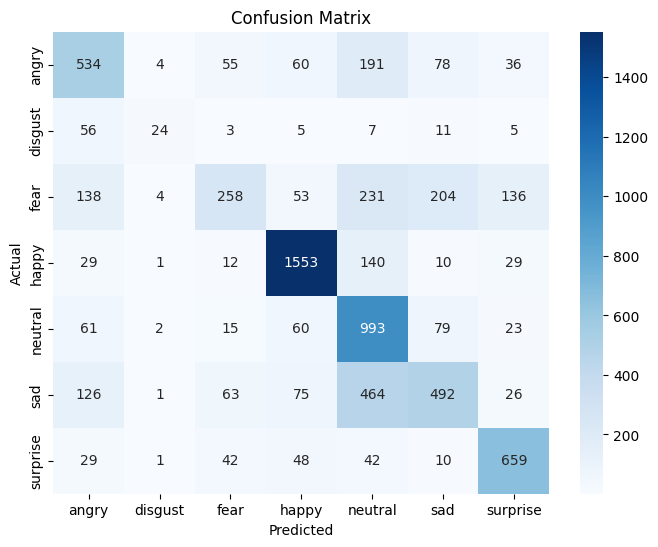

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Reset generator
test_generator.reset()

# Predictions
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = test_generator.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=emotion_labels,
            yticklabels=emotion_labels,
            cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
print("Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=emotion_labels))

Classification Report:

              precision    recall  f1-score   support

       angry       0.55      0.56      0.55       958
     disgust       0.65      0.22      0.32       111
        fear       0.58      0.25      0.35      1024
       happy       0.84      0.88      0.86      1774
     neutral       0.48      0.81      0.60      1233
         sad       0.56      0.39      0.46      1247
    surprise       0.72      0.79      0.76       831

    accuracy                           0.63      7178
   macro avg       0.62      0.56      0.56      7178
weighted avg       0.64      0.63      0.61      7178



Training another Model

In [30]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.3,
    horizontal_flip=True
)

# ✅ TRAIN → shuffle MUST be True
training_set = train_datagen.flow_from_directory(
    train_dir,
    batch_size=64,
    target_size=(48,48),
    shuffle=True,   # ✅ CORRECT
    color_mode='grayscale',
    class_mode='categorical'
)

# ✅ TEST → shuffle MUST be False
test_datagen = ImageDataGenerator(rescale=1./255)

test_set = test_datagen.flow_from_directory(
    test_dir,
    batch_size=64,
    target_size=(48,48),
    shuffle=False,   # ✅ CORRECT
    color_mode='grayscale',
    class_mode='categorical'
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [31]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   zoom_range=0.3,
                                   horizontal_flip=True)

training_set = train_datagen.flow_from_directory(train_dir,
                                                batch_size=64,
                                                target_size=(48,48),
                                                shuffle=False,
                                                color_mode='grayscale',
                                                class_mode='categorical')

test_datagen = ImageDataGenerator(rescale=1./255)
test_set = test_datagen.flow_from_directory(test_dir,
                                                batch_size=64,
                                                target_size=(48,48),
                                                shuffle=False,
                                                color_mode='grayscale',
                                                class_mode='categorical')

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [31]:
training_set.class_indices

{'angry': 0,
 'disgust': 1,
 'fear': 2,
 'happy': 3,
 'neutral': 4,
 'sad': 5,
 'surprise': 6}

In [32]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers

def get_model(input_size, classes=7):
     #Initialising the CNN
    model = tf.keras.models.Sequential()

    model.add(Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu', input_shape =input_size))
    model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))
    model.add(Dropout(0.25))

    model.add(Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.01)))
    model.add(Conv2D(256, kernel_size=(3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.01)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))
    model.add(Flatten())
    model.add(Dense(1024, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(classes, activation='softmax'))

    #Compliling the model
    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [33]:
row = 48
col = 48
fernet = get_model((row,col,1), classes=7) # Assuming 7 classes based on previous training
fernet.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 22, 22, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │    31,720,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │         7,175 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,116,743 (122.52 MB)

 Trainable params: 32,116,103 (122.51 MB)

 Non-trainable params: 640 (2.50 KB)

In [34]:
import datetime
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger

chk_path = 'fer2.h5'
log_dir = "checkpoint/logs/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

checkpoint = ModelCheckpoint(filepath=chk_path,
                             save_best_only=True,
                             verbose=1,
                             mode='min',
                             monitor='val_loss')

earlystop = EarlyStopping(monitor='val_loss',
                          min_delta=0,
                          patience=3,
                          verbose=1,
                          restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                              factor=0.2,
                              patience=6,
                              verbose=1,
                              min_delta=0.0001)
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
csv_logger = CSVLogger('training.log')

callbacks = [checkpoint, reduce_lr, csv_logger]

In [36]:
steps_per_epoch = training_set.n // training_set.batch_size
validation_steps = test_set.n // test_set.batch_size

hist = fernet.fit(x=training_set,
                 validation_data=test_set,
                 epochs=60,
                 callbacks=callbacks,
                 steps_per_epoch=steps_per_epoch,
                 validation_steps=validation_steps)

Epoch 1/60
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.2455 - loss: 5.0025
Epoch 1: val_loss improved from None to 9.38574, saving model to fer2.h5



Epoch 1: finished saving model to fer2.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 45s 78ms/step - accuracy: 0.2709 - loss: 4.3205 - val_accuracy: 0.0409 - val_loss: 9.3857 - learning_rate: 1.0000e-04
Epoch 2/60
  1/448 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.2969 - loss: 3.7536

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss improved from 9.38574 to 9.36321, saving model to fer2.h5



Epoch 2: finished saving model to fer2.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.2969 - loss: 3.7536 - val_accuracy: 0.0421 - val_loss: 9.3632 - learning_rate: 1.0000e-04
Epoch 3/60
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3152 - loss: 3.6848
Epoch 3: val_loss improved from 9.36321 to 3.18486, saving model to fer2.h5


...


Epoch 41: finished saving model to fer2.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 26s 59ms/step - accuracy: 0.6432 - loss: 1.0444 - val_accuracy: 0.6138 - val_loss: 1.1158 - learning_rate: 1.0000e-04
Epoch 42/60
  1/448 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.7188 - loss: 0.9743
Epoch 42: val_loss did not improve from 1.11582
448/448 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7188 - loss: 0.9743 - val_accuracy: 0.6081 - val_loss: 1.1232 - learning_rate: 1.0000e-04
Epoch 43/60
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.6534 - loss: 1.0234
Epoch 43: val_loss improved from 1.11582 to 1.10037, saving model to fer2.h5



Epoch 43: finished saving model to fer2.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.6544 - loss: 1.0227 - val_accuracy: 0.6327 - val_loss: 1.1004 - learning_rate: 1.0000e-04
Epoch 44/60
  1/448 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - accuracy: 0.6719 - loss: 1.1268
Epoch 44: val_loss did not improve from 1.10037
448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6719 - loss: 1.1268 - val_accuracy: 0.6297 - val_loss: 1.1019 - learning_rate: 1.0000e-04
Epoch 45/60
447/448 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6616 - loss: 0.9903
Epoch 45: val_loss improved from 1.10037 to 1.08465, saving model to fer2.h5



Epoch 45: finished saving model to fer2.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.6592 - loss: 1.0037 - val_accuracy: 0.6345 - val_loss: 1.0846 - learning_rate: 1.0000e-04
Epoch 46/60
  1/448 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.6719 - loss: 0.9456
Epoch 46: val_loss improved from 1.08465 to 1.08077, saving model to fer2.h5



Epoch 46: finished saving model to fer2.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6719 - loss: 0.9456 - val_accuracy: 0.6353 - val_loss: 1.0808 - learning_rate: 1.0000e-04
Epoch 47/60
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.6673 - loss: 0.9753
Epoch 47: val_loss did not improve from 1.08077
448/448 ━━━━━━━━━━━━━━━━━━━━ 26s 58ms/step - accuracy: 0.6677 - loss: 0.9762 - val_accuracy: 0.6244 - val_loss: 1.1331 - learning_rate: 1.0000e-04
Epoch 48/60
  1/448 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.5938 - loss: 1.1439
Epoch 48: val_loss did not improve from 1.08077
448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5938 - loss: 1.1439 - val_accuracy: 0.6263 - val_loss: 1.1317 - learning_rate: 1.0000e-04
Epoch 49/60
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.6819 - loss: 0.9447
Epoch 49: val_loss did not improve from 1.08077
448/448 ━━━━━━━━━━━━━━━━━━━━ 26s 58ms/step - accuracy: 0.6762 - loss: 0.9563 - val_accuracy: 0.6374 - val_loss


Epoch 55: finished saving model to fer2.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.7235 - loss: 0.8408 - val_accuracy: 0.6505 - val_loss: 1.0732 - learning_rate: 2.0000e-05
Epoch 56/60
  1/448 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.7812 - loss: 0.6726
Epoch 56: val_loss did not improve from 1.07323
448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7812 - loss: 0.6726 - val_accuracy: 0.6512 - val_loss: 1.0740 - learning_rate: 2.0000e-05
Epoch 57/60
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7308 - loss: 0.8209
Epoch 57: val_loss did not improve from 1.07323
448/448 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - accuracy: 0.7285 - loss: 0.8257 - val_accuracy: 0.6498 - val_loss: 1.0821 - learning_rate: 2.0000e-05
Epoch 58/60
  1/448 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.7188 - loss: 0.7749
Epoch 58: val_loss did not improve from 1.07323
448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7188 - loss: 0.7749 - val_accuracy: 0.6503 - val_los

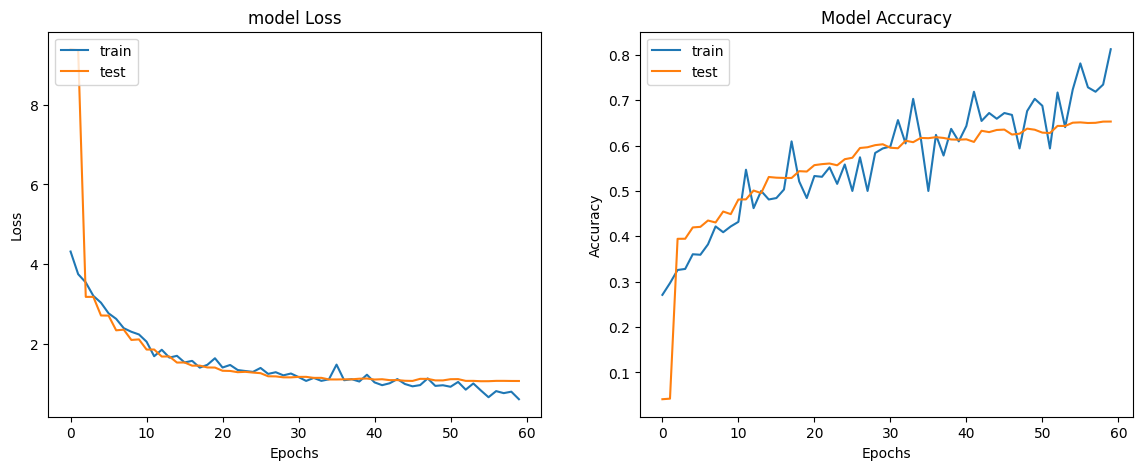

In [37]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,5))
plt.subplot(1,2,2)
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['train', 'test'], loc='upper left')

plt.subplot(1,2,1)
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['train', 'test'], loc='upper left')
plt.show()


In [38]:
train_loss, train_accu = fernet.evaluate(training_set)
test_loss, test_accu = fernet.evaluate(test_set)
print("final train accuracy = {:.2f} , validation accuracy = {:.2f}".format(train_accu*100, test_accu*100))

449/449 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.8042 - loss: 0.6545
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.6534 - loss: 1.0781
final train accuracy = 80.42 , validation accuracy = 65.34


In [46]:
train_eval_datagen = ImageDataGenerator(rescale=1./255)

train_eval_set = train_eval_datagen.flow_from_directory(
    train_dir,
    batch_size=64,
    target_size=(48,48),
    shuffle=False,   # ✅ important
    color_mode='grayscale',
    class_mode='categorical'
)

Found 28709 images belonging to 7 classes.


In [47]:
import numpy as np

train_eval_set.reset()

y_pred_train = model.predict(train_eval_set)
y_pred_train_classes = np.argmax(y_pred_train, axis=1)

y_true_train = train_eval_set.classes

449/449 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step


In [48]:
from sklearn.metrics import confusion_matrix

cm_train = confusion_matrix(y_true_train, y_pred_train_classes)
print(cm_train)

[[  30   52 3913    0    0    0    0]
 [   0    1  435    0    0    0    0]
 [  13   28 4056    0    0    0    0]
 [  27   32 7156    0    0    0    0]
 [  21   55 4889    0    0    0    0]
 [  22   71 4737    0    0    0    0]
 [   3   12 3156    0    0    0    0]]


In [46]:
fernet.save_weights('fernet.weights.h5')

Confusion Matrix and Classification on training set

449/449 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step
Confusion Matrix
[[ 533   46  440 1059  783  691  443]
 [  56    5   47  122   86   73   47]
 [ 573   47  521 1006  814  708  428]
 [ 983   90  889 1815 1429 1221  788]
 [ 666   53  558 1289  975  904  520]
 [ 633   52  546 1252  951  848  548]
 [ 415   27  369  801  661  547  351]]
Classification Report
              precision    recall  f1-score   support

       angry       0.14      0.13      0.14      3995
     disgust       0.02      0.01      0.01       436
        fear       0.15      0.13      0.14      4097
       happy       0.25      0.25      0.25      7215
     neutral       0.17      0.20      0.18      4965
         sad       0.17      0.18      0.17      4830
    surprise       0.11      0.11      0.11      3171

    accuracy                           0.18     28709
   macro avg       0.14      0.14      0.14     28709
weighted avg       0.17      0.18      0.17     28709



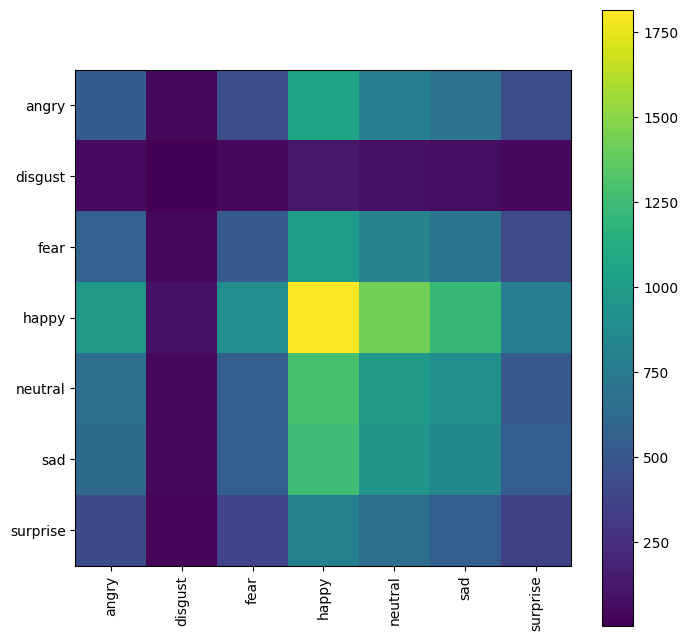

In [44]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_pred = fernet.predict(training_set)
y_pred = np.argmax(y_pred, axis=1)
class_labels = test_set.class_indices
class_labels = {v:k for k,v in class_labels.items()}

cm_train = confusion_matrix(training_set.classes, y_pred)
print('Confusion Matrix')
print(cm_train)
print('Classification Report')
target_names = list(class_labels.values())
print(classification_report(training_set.classes, y_pred, target_names=target_names))

plt.figure(figsize=(8,8))
plt.imshow(cm_train, interpolation='nearest')
plt.colorbar()
tick_mark = np.arange(len(target_names))
_ = plt.xticks(tick_mark, target_names, rotation=90)
_ = plt.yticks(tick_mark, target_names)

Confusion Matrix and Classification on test set

113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step
Confusion Matrix
[[ 559    5   90   41   96  140   27]
 [  37   51    2    1    5   11    4]
 [ 143    1  394   43  128  212  103]
 [  46    1   33 1484  113   58   39]
 [  73    1   67   88  765  208   31]
 [ 157    0  111   65  223  663   28]
 [  25    0   68   41   21   21  655]]
Classification Report
              precision    recall  f1-score   support

       angry       0.54      0.58      0.56       958
     disgust       0.86      0.46      0.60       111
        fear       0.52      0.38      0.44      1024
       happy       0.84      0.84      0.84      1774
     neutral       0.57      0.62      0.59      1233
         sad       0.50      0.53      0.52      1247
    surprise       0.74      0.79      0.76       831

    accuracy                           0.64      7178
   macro avg       0.65      0.60      0.62      7178
weighted avg       0.64      0.64      0.63      7178



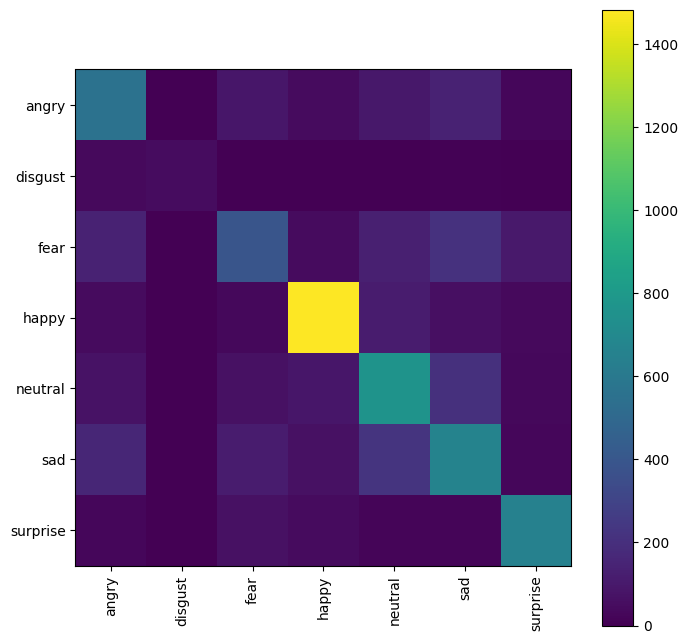

In [44]:
y_pred = fernet.predict(test_set)
y_pred = np.argmax(y_pred, axis=1)
class_labels = test_set.class_indices
class_labels = {v:k for k,v in class_labels.items()}

#from sklearn.metrics import classification_report, confusion_matrix
cm_test = confusion_matrix(test_set.classes, y_pred)
print('Confusion Matrix')
print(cm_test)
print('Classification Report')
target_names = list(class_labels.values())
print(classification_report(test_set.classes, y_pred, target_names=target_names))

plt.figure(figsize=(8,8))
plt.imshow(cm_test, interpolation='nearest')
plt.colorbar()
tick_mark = np.arange(len(target_names))
_ = plt.xticks(tick_mark, target_names, rotation=90)
_ = plt.yticks(tick_mark, target_names)

In [ ]:
import os

save_dir = '/content/drive/MyDrive/MoodMirror'
os.makedirs(save_dir, exist_ok=True)
model_path = os.path.join(save_dir, 'ferNet.h5')
fernet.save(model_path)

In [ ]:
os.listdir(save_dir)

['dataset.zip',
 'checkpoint_best.h5',
 'final_model.h5',
 '59%_fer2013.keras',
 '83%_ferNet.keras',
 'ferNet.keras',
 'class_labels.json',
 'ferNet.h5']

Testing Predictions of train model

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 836ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


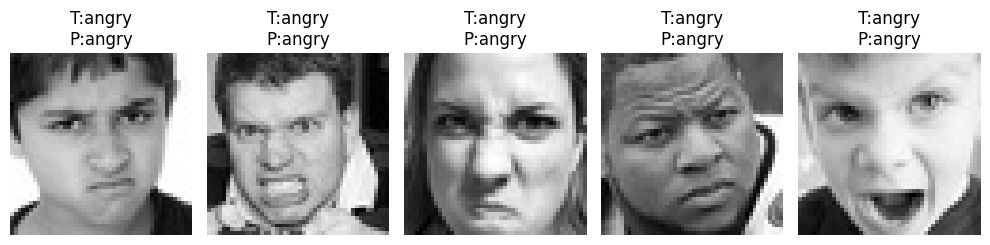

In [ ]:
import os
import random

emotion = 'angry'  # change emotion here
emotion_path = os.path.join(test_dir, emotion)

sample_images = random.sample(os.listdir(emotion_path), 5)

plt.figure(figsize=(10,4))

# Define emotion_dict
emotion_dict = {v: k for k, v in training_set.class_indices.items()}

for i, img_name in enumerate(sample_images):
    img_path = os.path.join(emotion_path, img_name)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (48,48))
    img_norm = img / 255.0
    img_input = img_norm.reshape(1,48,48,1)

    pred = fernet.predict(img_input)
    pred_emotion = emotion_dict[np.argmax(pred)]

    plt.subplot(1,5,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"T:{emotion}\nP:{pred_emotion}")
    plt.axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


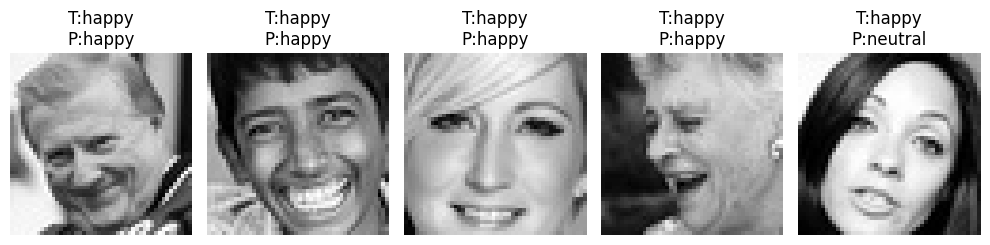

In [ ]:
import os
import random

emotion = 'happy'  # change emotion here
emotion_path = os.path.join(test_dir, emotion)

sample_images = random.sample(os.listdir(emotion_path), 5)

plt.figure(figsize=(10,4))

# Define emotion_dict
emotion_dict = {v: k for k, v in training_set.class_indices.items()}

for i, img_name in enumerate(sample_images):
    img_path = os.path.join(emotion_path, img_name)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (48,48))
    img_norm = img / 255.0
    img_input = img_norm.reshape(1,48,48,1)

    pred = fernet.predict(img_input)
    pred_emotion = emotion_dict[np.argmax(pred)]

    plt.subplot(1,5,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"T:{emotion}\nP:{pred_emotion}")
    plt.axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


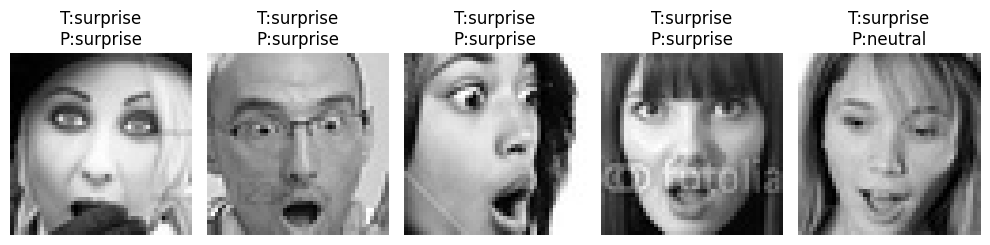

In [ ]:
import os
import random

emotion = 'surprise'  # change emotion here
emotion_path = os.path.join(test_dir, emotion)

sample_images = random.sample(os.listdir(emotion_path), 5)

plt.figure(figsize=(10,4))

# Define emotion_dict
emotion_dict = {v: k for k, v in training_set.class_indices.items()}

for i, img_name in enumerate(sample_images):
    img_path = os.path.join(emotion_path, img_name)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (48,48))
    img_norm = img / 255.0
    img_input = img_norm.reshape(1,48,48,1)

    pred = fernet.predict(img_input)
    pred_emotion = emotion_dict[np.argmax(pred)]

    plt.subplot(1,5,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"T:{emotion}\nP:{pred_emotion}")
    plt.axis('off')

plt.tight_layout()
plt.show()